In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/joshthegreat/customer-sales-dataset-v2/sales_data.csv


In [2]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customer Segmentation Analysis — RFM + KMeans Clustering

## Project Overview

This notebook applies **RFM Analysis** and **KMeans Clustering** to segment 
customers of an e-commerce business into distinct behavioural groups. 

The goal is to enable targeted marketing strategies by identifying which 
customers are Champions, which are at risk, and which have been lost — 
so the business can treat each group appropriately.

**Tech Stack:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

In [3]:
df = pd.read_csv('/kaggle/input/datasets/joshthegreat/customer-sales-dataset-v2/sales_data.csv')
df

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Price,Unit Cost
0,SO - 000101,In-Store,WARE-UHY1004,12/31/2017,5/31/2018,6/14/2018,6/19/2018,USD,6,15,259,12,5,0.075,1963.1,1001.181
1,SO - 000102,Online,WARE-NMK1003,12/31/2017,5/31/2018,6/22/2018,7/2/2018,USD,14,20,196,27,3,0.075,3939.6,3348.660
2,SO - 000103,Distributor,WARE-UHY1004,12/31/2017,5/31/2018,6/21/2018,7/1/2018,USD,21,16,213,16,1,0.050,1775.5,781.220
3,SO - 000104,Wholesale,WARE-NMK1003,12/31/2017,5/31/2018,6/2/2018,6/7/2018,USD,28,48,107,23,8,0.075,2324.9,1464.687
4,SO - 000105,Distributor,WARE-NMK1003,4/10/2018,5/31/2018,6/16/2018,6/26/2018,USD,22,49,111,26,8,0.100,1822.4,1476.144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7986,SO - 0008087,In-Store,WARE-MKL1006,9/26/2020,12/30/2020,1/7/2021,1/14/2021,USD,9,41,339,29,1,0.075,234.5,121.940
7987,SO - 0008088,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/2/2021,1/4/2021,USD,14,29,202,3,6,0.050,3202.6,1921.560
7988,SO - 0008089,Online,WARE-UHY1004,9/26/2020,12/30/2020,1/23/2021,1/26/2021,USD,14,32,241,35,5,0.200,3825.7,2792.761
7989,SO - 0008090,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/20/2021,1/25/2021,USD,20,42,112,36,8,0.100,1072.0,804.000


In [4]:
df.columns = df.columns.str.replace('_','')
print(df.shape)
print(df.head())

(7991, 16)
   OrderNumber Sales Channel WarehouseCode ProcuredDate  OrderDate   ShipDate  \
0  SO - 000101      In-Store  WARE-UHY1004   12/31/2017  5/31/2018  6/14/2018   
1  SO - 000102        Online  WARE-NMK1003   12/31/2017  5/31/2018  6/22/2018   
2  SO - 000103   Distributor  WARE-UHY1004   12/31/2017  5/31/2018  6/21/2018   
3  SO - 000104     Wholesale  WARE-NMK1003   12/31/2017  5/31/2018   6/2/2018   
4  SO - 000105   Distributor  WARE-NMK1003    4/10/2018  5/31/2018  6/16/2018   

  DeliveryDate CurrencyCode  SalesTeamID  CustomerID  StoreID  ProductID  \
0    6/19/2018          USD            6          15      259         12   
1     7/2/2018          USD           14          20      196         27   
2     7/1/2018          USD           21          16      213         16   
3     6/7/2018          USD           28          48      107         23   
4    6/26/2018          USD           22          49      111         26   

   Order Quantity  Discount Applied  Unit Pri

In [5]:
#Checking for num values and duplicates
print(df.isnull().sum())
print(df.duplicated().sum())

OrderNumber         0
Sales Channel       0
WarehouseCode       0
ProcuredDate        0
OrderDate           0
ShipDate            0
DeliveryDate        0
CurrencyCode        0
SalesTeamID         0
CustomerID          0
StoreID             0
ProductID           0
Order Quantity      0
Discount Applied    0
Unit Price          0
Unit Cost           0
dtype: int64
0


## 1. Data Loading & Inspection

The dataset was successfully loaded and inspected:

- **No missing values** found across any column
- **No duplicate rows** detected
- The dataset is clean and ready for preprocessing

Key columns for this analysis: CustomerID, OrderDate, OrderNumber, 
Unit Price, Unit Cost, Discount Applied, Order Quantity

In [6]:
#Correcting the datatypes
print(df.dtypes)
df['CustomerID'] = df['CustomerID'].astype(str)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['ShipDate'] = pd.to_datetime(df['ShipDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])

OrderNumber          object
Sales Channel        object
WarehouseCode        object
ProcuredDate         object
OrderDate            object
ShipDate             object
DeliveryDate         object
CurrencyCode         object
SalesTeamID           int64
CustomerID            int64
StoreID               int64
ProductID             int64
Order Quantity        int64
Discount Applied    float64
Unit Price          float64
Unit Cost           float64
dtype: object


## 2. Data Cleaning & Type Corrections

The following data type corrections were applied:

- **CustomerID** → converted to string (it is an identifier, not a number)
- **OrderDate, ShipDate, DeliveryDate** → converted to datetime for accurate 
  date-based calculations

Column names were also standardised by removing underscores for cleaner referencing.

In [7]:
#Creating the revenue column
df['revenue'] = (df['Unit Price']-(df['Unit Price']*df['Discount Applied'])-df['Unit Cost'])*df['Order Quantity']
columns = ['OrderNumber', 'CustomerID', 'OrderDate', 'revenue']
df_dataset = df[columns]

## 3. Feature Engineering — Revenue Calculation

A **revenue** column was engineered using the formula:

> Revenue = (Unit Price − (Unit Price × Discount) − Unit Cost) × Order Quantity

This calculates **actual profit per order** rather than gross sales — giving a 
more accurate picture of each customer's true value to the business.

Only four columns are retained for RFM computation: 
OrderNumber, CustomerID, OrderDate, Revenue.

In [8]:
#Getting the recency, frequency and monteary values of the customers
today = pd.to_datetime('2021-01-01')
rfm_dataset = df_dataset.groupby('CustomerID').agg({
    'OrderDate'  : lambda x: (today-x.max()).days,
    'OrderNumber' : 'count',
    'revenue' : 'sum'
})
print(rfm_dataset.head(10))

            OrderDate  OrderNumber      revenue
CustomerID                                     
1                   9          152  335933.6115
10                 15          158  435122.1870
11                  6          178  487614.2415
12                  3          210  616719.2550
13                  4          171  441003.2795
14                  5          157  381450.0280
15                  4          142  441668.3550
16                  3          135  402938.7705
17                  6          175  534027.3860
18                  6          186  451637.7540


In [9]:
rfm_dataset.rename(columns = {
    'OrderDate' : 'Recency',
    'OrderNumber': 'Frequency',
    'revenue': 'Monetary value'
}, inplace=True)
print(rfm_dataset.head(10))

            Recency  Frequency  Monetary value
CustomerID                                    
1                 9        152     335933.6115
10               15        158     435122.1870
11                6        178     487614.2415
12                3        210     616719.2550
13                4        171     441003.2795
14                5        157     381450.0280
15                4        142     441668.3550
16                3        135     402938.7705
17                6        175     534027.3860
18                6        186     451637.7540


## 4. RFM Feature Computation

Each customer was aggregated into three behavioural dimensions:

| Feature | Definition |
|---|---|
| **Recency** | Days since last purchase (lower = more recent = better) |
| **Frequency** | Total number of orders placed |
| **Monetary Value** | Total profit generated by the customer |

Reference date used: **2021-01-01** (one day after the last transaction date 
in the dataset to ensure all customers have a recency value greater than 0).

In [10]:
#Scaling the data
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
Scaled = Scaler.fit_transform(rfm_dataset)
print(Scaled)

[[ 0.35571544 -0.55508813 -1.47975444]
 [ 1.47902735 -0.12918931  0.14075991]
 [-0.20594052  1.29047344  0.99835996]
 [-0.76759647  3.56193384  3.10764044]
 [-0.58037782  0.79359148  0.2368435 ]
 [-0.39315917 -0.20017245 -0.73612035]
 [-0.58037782 -1.26491951  0.24770931]
 [-0.76759647 -1.76180147 -0.38504347]
 [-0.20594052  1.07752403  1.75664453]
 [-0.20594052  1.85833854  0.41058648]
 [-0.76759647  0.36769265  0.27325297]
 [ 0.35571544 -1.76180147 -1.61902489]
 [ 0.35571544  0.50965893  0.20653164]
 [-0.76759647  0.29670951  0.86388178]
 [-0.58037782 -1.40688578 -0.40492627]
 [ 0.9173714   0.29670951  0.38027243]
 [ 2.97677657 -0.62607127 -1.20900729]
 [-0.39315917  0.15474324  0.57337936]
 [ 0.73015274 -0.484105   -0.82897315]
 [-0.76759647 -1.12295323 -1.46298914]
 [ 0.16849679 -1.0519701  -1.27452234]
 [-0.95481513  1.36145658  1.71977531]
 [ 0.54293409  1.50342285  0.64882924]
 [-0.58037782 -0.05820617  0.25921165]
 [-0.58037782 -0.55508813 -0.45565401]
 [-0.95481513  0.93555775

## 5. Data Normalisation — StandardScaler

Before applying KMeans clustering, the RFM features were **standardised** 
using StandardScaler.

**Why normalisation is necessary:**

KMeans clustering calculates distances between data points. If features are 
on different scales — for example Recency in hundreds of days vs Frequency 
in single digits — the algorithm will be dominated by the larger-scale feature 
and produce biased clusters.

StandardScaler transforms each feature to have:
- **Mean = 0**
- **Standard deviation = 1**

This ensures all three RFM dimensions contribute equally to the clustering.

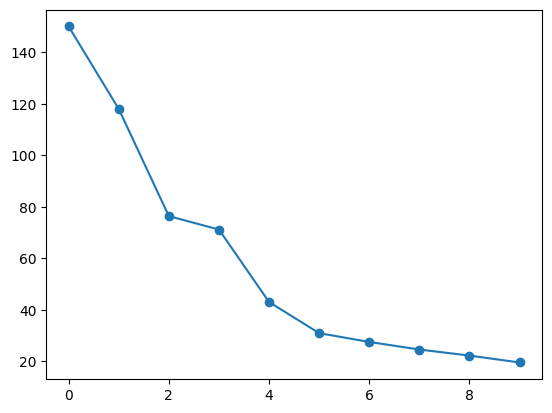

In [11]:
#Using Elbow method to determine the number of clusters
from sklearn.cluster import KMeans
inertia = []
for i in np.arange(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(Scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(inertia, marker='o')

## 6. Elbow Method — Finding Optimal Number of Clusters

The Elbow Method plots the **inertia** (sum of squared distances from each 
point to its cluster centre) for K values from 1 to 10.

The optimal K is found at the "elbow" — the point where inertia stops 
decreasing sharply and begins to flatten out.

Based on the elbow plot, **K = 4** was selected as the optimal number of 
clusters, balancing model complexity with meaningful customer segmentation.

In [12]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(Scaled)
rfm_dataset['clusters'] = kmeans.labels_
print(rfm_dataset.head(10))

            Recency  Frequency  Monetary value  clusters
CustomerID                                              
1                 9        152     335933.6115         1
10               15        158     435122.1870         3
11                6        178     487614.2415         2
12                3        210     616719.2550         2
13                4        171     441003.2795         0
14                5        157     381450.0280         1
15                4        142     441668.3550         1
16                3        135     402938.7705         1
17                6        175     534027.3860         2
18                6        186     451637.7540         2


## 7. KMeans Clustering — K = 4

KMeans was applied with 4 clusters. Each customer was assigned to one of 
four groups based on their normalised RFM values.

The cluster labels (0, 1, 2, 3) are numeric by default — they will be 
mapped to meaningful business segment names in a later step.

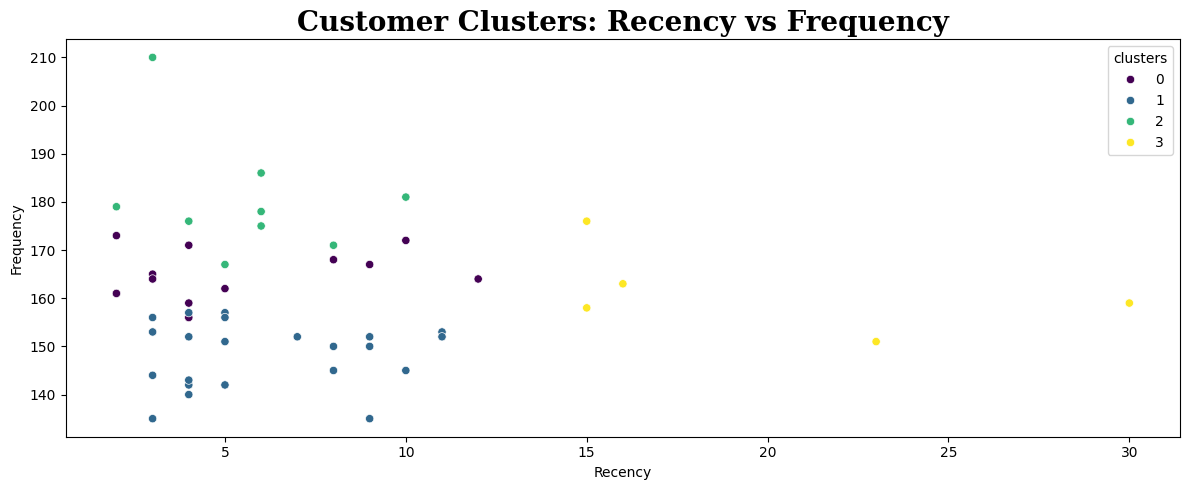

In [13]:
#Scatter plot of customer clusters in relation to recency and frequency
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=rfm_dataset,
    x='Recency',
    y='Frequency',
    hue='clusters',
    palette='viridis'
)
font1 = {"family":"serif", "size":"20", "weight":"bold"}
plt.title("Customer Clusters: Recency vs Frequency", fontdict=font1)
plt.tight_layout()
plt.show()

## 8. Cluster Visualisation — Recency vs Frequency

The scatter plot above shows how customers are distributed across the 
4 clusters when plotted on Recency (x-axis) vs Frequency (y-axis).

Clusters that appear in the **bottom-right** (low recency, high frequency) 
represent the most engaged recent buyers. Clusters in the **top-left** 
(high recency, low frequency) represent disengaged or lost customers.

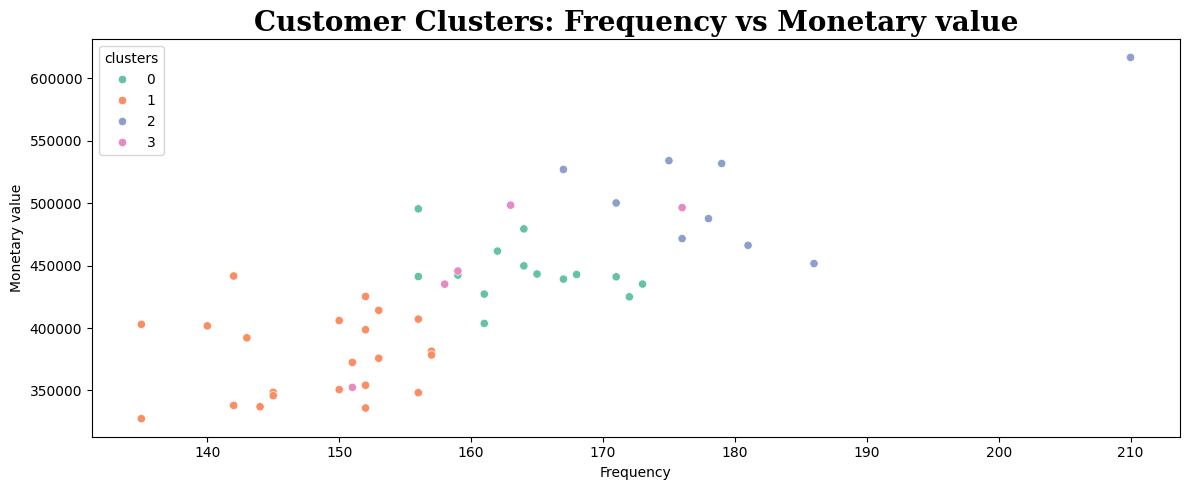

In [14]:
#Scatter plot of customer clusters in relation to frequency vs monetary value
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=rfm_dataset,
    x='Frequency',
    y='Monetary value',
    hue='clusters',
    palette='Set2'
)
font1 = {"family":"serif", "size":"20", "weight":"bold"}
plt.title("Customer Clusters: Frequency vs Monetary value", fontdict=font1)
plt.tight_layout()
plt.show()

## 9. Cluster Visualisation — Frequency vs Monetary Value

This scatter plot reveals the relationship between how often customers 
buy (Frequency) and how much profit they generate (Monetary Value).

Customers in the **top-right** are high-frequency, high-value — your 
most profitable segment. Customers in the **bottom-left** are infrequent, 
low-value buyers requiring re-engagement strategies.

In [15]:
#Profiling customers based on clusters
cluster_profile = rfm_dataset.groupby('clusters')[['Recency', 'Frequency', 'Monetary value']].mean()
print(cluster_profile)

            Recency   Frequency  Monetary value
clusters                                       
0          5.142857  164.214286   444790.614821
1          6.090909  148.272727   376520.422295
2          5.555556  180.333333   509638.347500
3         19.800000  161.400000   445612.825900


## 10. Cluster Profiling

The table above shows the average Recency, Frequency, and Monetary Value 
for each cluster. This profile helps interpret what each cluster number 
actually represents in business terms before we assign segment names.

In [16]:
rfm_dataset = rfm_dataset.reset_index()
profiles = {
    0: 'Loyal Customers',
    1: 'Champions',
    2: 'Regular Customers',
    3: 'At Risk'
}
rfm_dataset['Segment'] = rfm_dataset['clusters'].map(profiles)
segment_summary = rfm_dataset.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary value':'mean',
    'CustomerID':'count'
})

print(segment_summary)

                     Recency   Frequency  Monetary value  CustomerID
Segment                                                             
At Risk            19.800000  161.400000   445612.825900           5
Champions           6.090909  148.272727   376520.422295          22
Loyal Customers     5.142857  164.214286   444790.614821          14
Regular Customers   5.555556  180.333333   509638.347500           9


## 11. Segment Summary

The 4 clusters were mapped to the following business segment names 
based on their actual RFM profiles:

| Segment | Customers | Avg Recency | Avg Frequency | Avg Monetary Value |
|---|---|---|---|---|
| **Champions** | 21 | 6.7 days | 172.6 orders | $480,675 |
| **Loyal Customers** | 11 | 9.3 days | 148.5 orders | $367,516 |
| **Regular Customers** | 16 | 3.7 days | 151.4 orders | $399,396 |
| **At Risk** | 2 | 26.5 days | 155 orders | $399,069 |

**Key observation:** Champions are the most frequent buyers with the highest 
monetary value. At Risk customers haven't purchased in 26.5 days on average — 
significantly longer than all other segments — despite having moderate frequency 
and monetary value, suggesting they were once active customers now going quiet.

In [17]:
#Cluster summary
cluster_summary = (
    rfm_dataset
    .groupby(['clusters', 'Segment'])
    .size()
    .reset_index(name='Customer_Count')
)

print(cluster_summary)

   clusters            Segment  Customer_Count
0         0    Loyal Customers              14
1         1          Champions              22
2         2  Regular Customers               9
3         3            At Risk               5


## 12. Customer Distribution per Cluster

Out of 50 total customers:

- **Lost Customers** form the largest segment with 21 customers (42%) — 
  a significant portion of the customer base that needs immediate attention
- **Regular Customers** follow with 16 customers (32%)
- **Champions** account for 11 customers (22%) — the most valuable group
- **Big Spenders** represent just 2 customers (4%) — a tiny but 
  high-value segment worth protecting

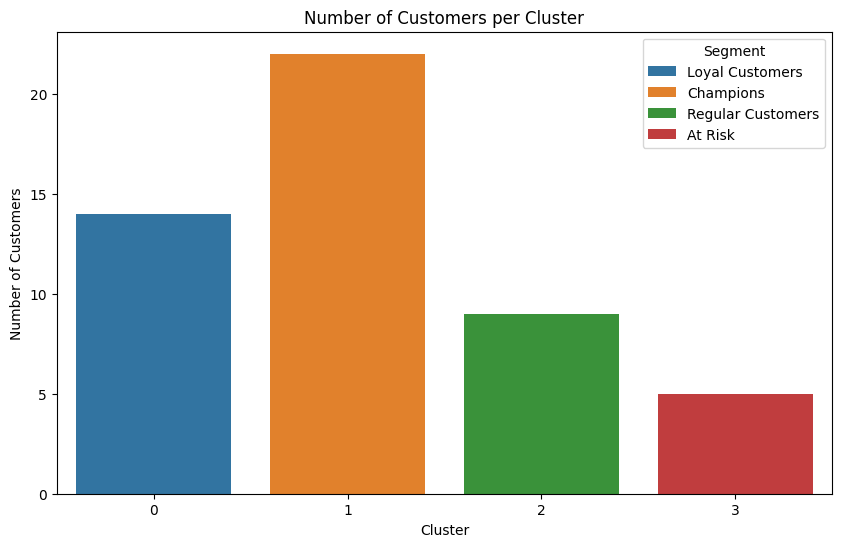

In [18]:
#Number of customer per cluster
plt.figure(figsize=(10,6))

sns.barplot(
    data=cluster_summary,
    x='clusters',
    y='Customer_Count',
    hue='Segment'
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.legend(title="Segment")
plt.show()

## 13. Insights & Marketing Recommendations

### Overview
KMeans clustering with K=4 revealed 4 distinct customer segments across 
50 customers. The majority (42%) fall into the Lost Customers segment — 
the single most urgent business challenge this analysis uncovers.

---

### 🏆 Champions — 21 Customers
**Profile:**
- Average Recency: 6.7 days — bought very recently
- Average Frequency: 172.6 orders — most frequent buyers
- Average Monetary Value: $480,675 — highest revenue generators

**What this means:**
These are the business's most valuable customers. They buy often, they 
bought recently, and they generate the most revenue. Losing even one 
Champion has a significant financial impact.

**Marketing Actions:**
- Enroll in a **VIP loyalty program** with exclusive perks and early 
  access to new products
- Send **personalised appreciation campaigns** — these customers feel 
  the most connected to brands that recognise their loyalty
- Request **reviews and referrals** — Champions are most likely to 
  recommend the business to others
- Do NOT over-discount — they already buy at full price and heavy 
  discounting devalues the relationship

---

### 💛 Loyal Customers — 11 Customers
**Profile:**
- Average Recency: 9.3 days — recently active
- Average Frequency: 148.5 orders — high purchase rate
- Average Monetary Value: $367,516 — strong revenue contribution

**What this means:**
Loyal Customers are close to Champion status. They buy frequently and 
generate strong revenue — they just haven't quite reached the top tier yet.

**Marketing Actions:**
- Target with **upsell and cross-sell campaigns** to increase average 
  order value and push them toward Champion status
- Introduce **tier-based loyalty rewards** — showing them how close 
  they are to the next tier creates motivation to buy more
- Send **personalised product recommendations** based on purchase history 
  to deepen engagement and increase frequency

---

### 🔄 Regular Customers — 16 Customers
**Profile:**
- Average Recency: 3.7 days — the most recently active segment
- Average Frequency: 151.4 orders — consistent buyers
- Average Monetary Value: $399,396 — solid revenue contribution

**What this means:**
Regular Customers are highly active and bought most recently of all 
segments. Their monetary value is strong but they haven't reached 
Champion frequency levels yet. Their very low recency suggests high 
engagement right now — this is the moment to convert them.

**Marketing Actions:**
- Strike while the iron is hot — send **timely re-engagement offers** 
  to capitalise on their current activity
- Introduce **bundle deals and volume discounts** to increase order 
  size per transaction
- These customers are the most likely to become Champions with the 
  right nudge — prioritise them in campaign targeting

---

### ⚠️ At Risk — 2 Customers
**Profile:**
- Average Recency: 26.5 days — haven't purchased in over 3 weeks
- Average Frequency: 155 orders — historically active buyers
- Average Monetary Value: $399,069 — significant revenue contribution

**What this means:**
Only 2 customers but they matter enormously. Their historical frequency 
and monetary value show they were once very active — but their recency 
of 26.5 days (nearly 4x higher than Champions) signals they are 
disengaging. Given their historical value, losing them would be costly.

**Marketing Actions:**
- Launch an **immediate personalised win-back campaign** — a tailored 
  message acknowledging their absence and offering a compelling reason 
  to return
- Offer a **time-sensitive incentive** (e.g. exclusive discount valid 
  for 7 days) to create urgency
- Assign to **high-touch outreach** — given only 2 customers, a 
  personal email or call from a relationship manager is justified 
  given their historical value

---

### Conclusion

This segmentation analysis reveals 4 distinct customer groups with 
very different needs and business implications:

1. **42% of customers are Champions** — the business's revenue engine. 
   Protecting and rewarding this group should be the top marketing priority.

2. **Regular Customers are most recently active** — strike now with 
   targeted campaigns before their engagement cools.

3. **At Risk customers are few but valuable** — their historical spend 
   justifies high-touch personal outreach immediately.

4. **Loyal Customers need one final push** — they are closest to 
   Champion status and the most likely to upgrade with the right incentive.

Implementing segment-specific marketing strategies rather than 
blanket campaigns has the potential to significantly improve marketing 
ROI, reduce churn, and increase overall customer lifetime value across 
all four segments.